# Circadiaan ML — Visualisatie & Inzichten

**Project R.E.M. · Visualisatienotebook**

Laad de opgeslagen modellen en data uit `models/circadian_ml/models.pkl` en visualiseer:
- Persoonlijke circadiaanse stresscurves
- Feature matrix overzicht
- Modelresultaten per deelnemer
- Verklarende analyse: Ridge coëfficiënten, permutation importance, SHAP
- Stressdeltatoets
- Robuustheidschecks: LOPO, ablatie

**Vereiste:** Voer eerst `ml/circadian_ml.ipynb` uit met `REUSE_MODEL = False`.

In [1]:
from __future__ import annotations

import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Configuratie ─────────────────────────────────────────────────────────────
# PARTICIPANT: "all" → alle deelnemers; of bijv. "kokosnoot" voor één deelnemer
PARTICIPANT = "all"

FEATURE_COLS = [
    "baseline_deviation_entry",
    "hr_baseline_deviation",
    "hour_of_day",
    "day_of_week",
    "playlist_calm",
    "playlist_energy",
    "mood_before_score",
    "bb_start",
    "days_since_last_session",
    "during_stress_mean",
    "post_stress_mean",
    "during_hr_mean",
    "post_hr_mean",
    "pre_state_encoded",
    "hrv_rmssd",
    "avg_resp_daily",
]

TARGET_COLS = {"mood_delta": "Stemming Delta", "stress_delta": "Stress Delta"}

In [3]:
# ── Paden ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT        = Path().resolve().parent.parent
DATA_ROOT           = PROJECT_ROOT / "data"
ANALYSIS_DIR        = DATA_ROOT / "analysis"
COMBINED_DIR        = ANALYSIS_DIR / "circadian_baselines"
MODELS_DIR          = PROJECT_ROOT / "models" / "circadian_ml"
FEATURE_MATRIX_PATH = COMBINED_DIR / "feature_matrix.csv"

# ── Donker thema ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1218",
    "axes.facecolor":   "#181e2a",
    "axes.edgecolor":   "#4a5568",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#a0aec0",
    "ytick.color":      "#a0aec0",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.alpha":       0.4,
    "legend.facecolor": "#1a2035",
    "legend.edgecolor": "#4a5568",
    "figure.dpi":       120,
    "font.family":      "monospace",
})

OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

## Modellen & data laden

In [4]:
models_path = MODELS_DIR / "models.pkl"
if not models_path.exists():
    raise FileNotFoundError(
        f"Opgeslagen modellen niet gevonden: {models_path}\n"
        "Voer eerst ml/1_circadian_ml.ipynb uit met REUSE_MODEL = False."
    )

with open(models_path, "rb") as f:
    saved = pickle.load(f)

all_comparisons = saved["comparisons"]
all_results     = saved["results"]
all_fitted      = saved["fitted"]
all_X           = saved["X_data"]
all_y           = saved["y_data"]
all_groups      = saved["groups"]
feature_names   = saved["feature_names"]

fm = pd.read_csv(FEATURE_MATRIX_PATH)

# Filter op PARTICIPANT indien opgegeven
if PARTICIPANT == "all":
    participants = sorted(fm["participant"].unique().tolist())
else:
    participants = [PARTICIPANT]
    fm = fm[fm["participant"].isin(participants)]

print(f"Modellen geladen vanuit {models_path}")
print(f"Deelnemers: {participants}")
print(f"Sessies: {len(fm)}")

Modellen geladen vanuit C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\circadian_ml\models.pkl
Deelnemers: ['bosbes', 'kokosnoot', 'limoen', 'peer']
Sessies: 82


## 1. Circadiaanse stresscurves

De persoonlijke 24-uurscurve van elke deelnemer, berekend op niet-sessiedagen.
Dit is hun 'verwachte' stress op elk uur — de referentie waartegen sessieafwijkingen worden gemeten.

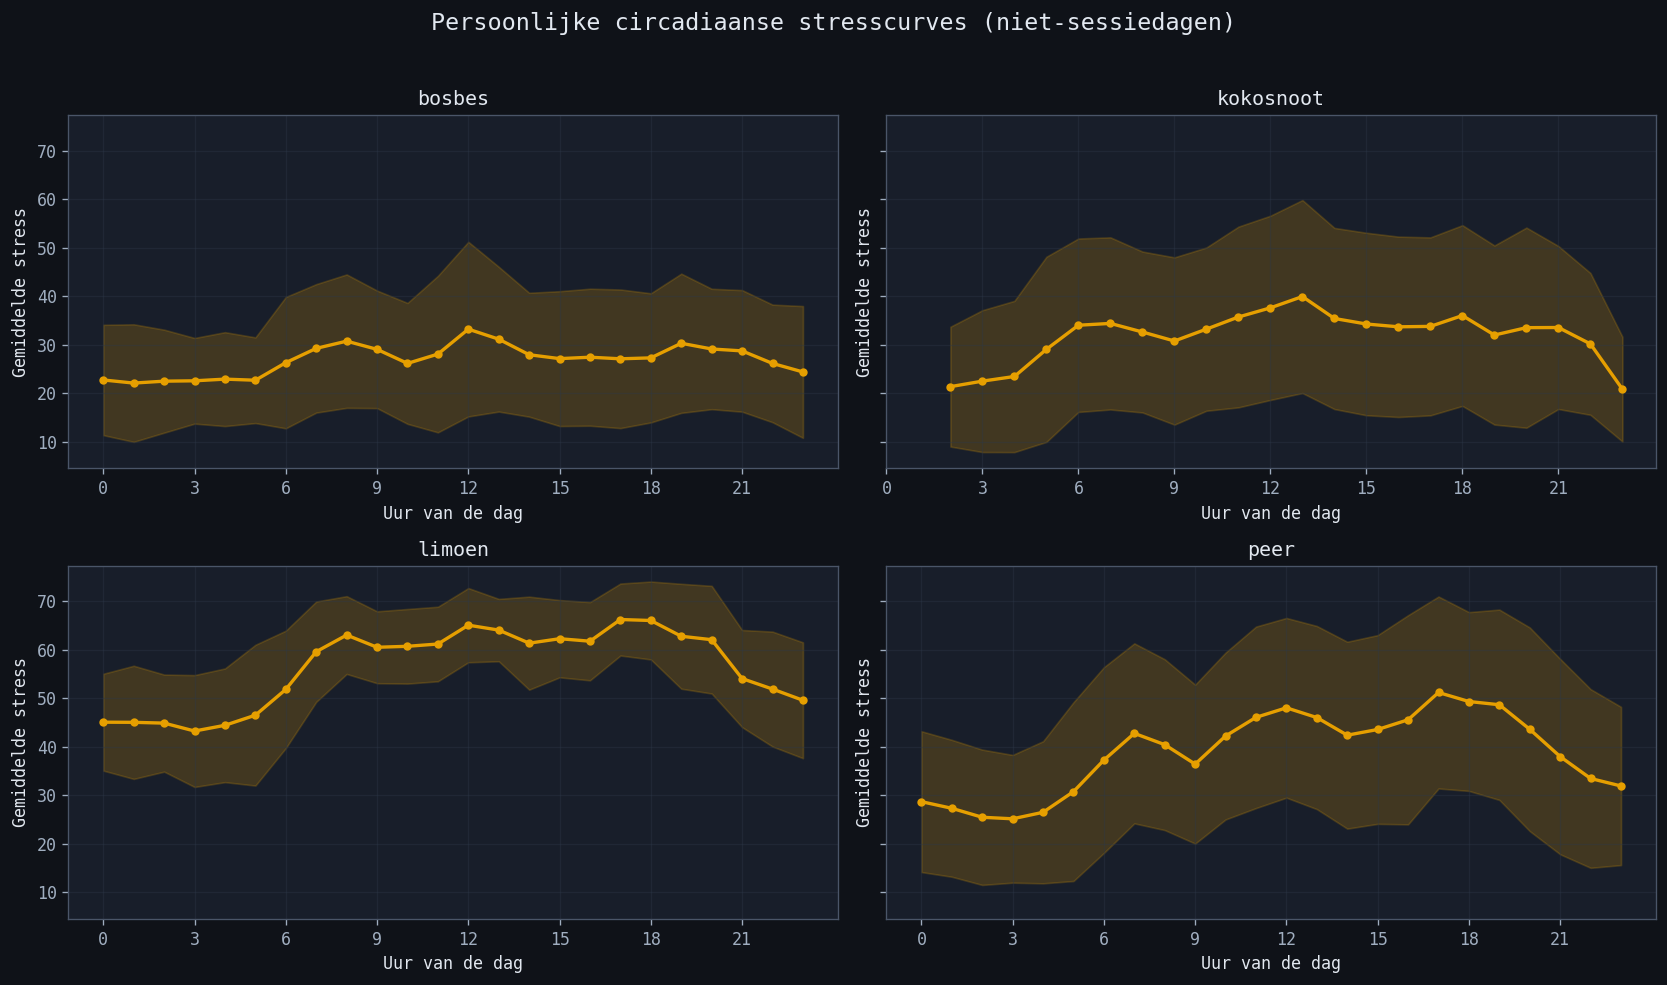

In [5]:
n = len(participants)
ncols = min(n, 2)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharey=True,
                         squeeze=False)

for ax, p in zip(axes.flat, participants):
    bl_path = ANALYSIS_DIR / p / "circadian_baselines" / "hourly_baseline.csv"
    if bl_path.exists():
        bl = pd.read_csv(bl_path)
        valid = bl["mean_stress"].notna()
        ax.plot(bl["hour"], bl["mean_stress"], "o-", linewidth=2,
                markersize=4, color=OKABE_ITO[0])
        ax.fill_between(
            bl.loc[valid, "hour"],
            bl.loc[valid, "mean_stress"] - bl.loc[valid, "std_stress"],
            bl.loc[valid, "mean_stress"] + bl.loc[valid, "std_stress"],
            alpha=0.2, color=OKABE_ITO[0],
        )
        ax.set_title(p, fontsize=12)
        ax.set_xticks(range(0, 24, 3))
        ax.set_xlabel("Uur van de dag")
        ax.set_ylabel("Gemiddelde stress")
        ax.grid(True)
    else:
        ax.text(0.5, 0.5, f"Geen baseline voor {p}", ha="center", va="center",
                transform=ax.transAxes)

# Verberg lege subplots
for ax in axes.flat[n:]:
    ax.set_visible(False)

fig.suptitle("Persoonlijke circadiaanse stresscurves (niet-sessiedagen)",
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

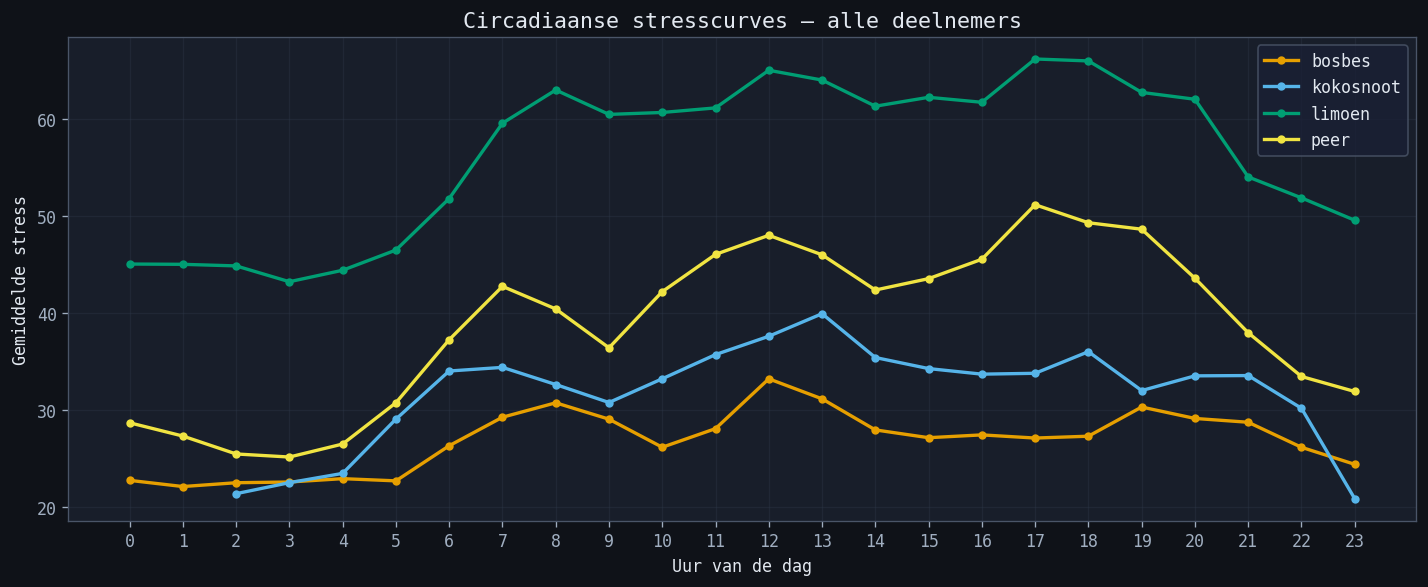

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, p in enumerate(participants):
    bl_path = ANALYSIS_DIR / p / "circadian_baselines" / "hourly_baseline.csv"
    if bl_path.exists():
        bl = pd.read_csv(bl_path)
        ax.plot(bl["hour"], bl["mean_stress"], "o-",
                label=p, color=OKABE_ITO[i % len(OKABE_ITO)],
                linewidth=2, markersize=4)

ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddelde stress")
ax.set_title("Circadiaanse stresscurves — alle deelnemers", fontsize=13)
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

## 2. Feature matrix — overzicht

Één rij per luistersessie. Features zijn circadiaan afwijkingen, tijdscontext,
playlisttype, stemming en Body Battery. HRV is opgenomen maar zwaar NaN
(alleen peer heeft waarden).

In [7]:
print(f"Totaal sessies: {len(fm)}")
print("\nSessies per deelnemer:")
display(fm["participant"].value_counts().to_frame())

print("\nNaN per feature (model inputs):")
nan_counts = fm[FEATURE_COLS + list(all_comparisons['mood_delta'].columns[:0])].isna().sum()
nan_pct    = (fm[FEATURE_COLS].isna().mean() * 100).round(1)
nan_df     = pd.DataFrame({"NaN count": fm[FEATURE_COLS].isna().sum(), "NaN %": nan_pct})
display(nan_df[nan_df["NaN count"] > 0].sort_values("NaN %", ascending=False))

Totaal sessies: 82

Sessies per deelnemer:


,count
participant,
kokosnoot,40
peer,30
limoen,8
bosbes,4



NaN per feature (model inputs):


,NaN count,NaN %
hrv_rmssd,52,63.4
post_hr_mean,33,40.2
during_hr_mean,30,36.6
hr_baseline_deviation,26,31.7
baseline_deviation_entry,15,18.3
post_stress_mean,14,17.1
during_stress_mean,14,17.1
bb_start,12,14.6
avg_resp_daily,11,13.4
days_since_last_session,4,4.9


In [8]:
print("Feature samenvatting (model inputs + targets):")
display(fm[FEATURE_COLS + ["mood_delta", "stress_delta"]].describe().round(2))

Feature samenvatting (model inputs + targets):


,baseline_deviation_entry,hr_baseline_deviation,hour_of_day,day_of_week,playlist_calm,playlist_energy,mood_before_score,bb_start,days_since_last_session,during_stress_mean,post_stress_mean,during_hr_mean,post_hr_mean,pre_state_encoded,hrv_rmssd,avg_resp_daily,mood_delta,stress_delta
count,67.00,56.00,82.00,82.00,82.00,82.00,82.00,70.00,78.00,68.00,68.00,52.00,49.00,82.00,30.00,71.00,82.00,64.00
mean,2.40,0.80,11.54,2.30,0.37,0.45,6.62,47.17,4.36,36.79,38.98,85.11,84.21,1.15,26.60,15.25,-0.18,-2.05
std,14.31,8.46,4.15,1.76,0.48,0.50,1.71,20.87,4.91,13.51,13.21,10.52,8.58,1.08,4.30,1.22,2.45,12.78
min,-24.85,-15.33,6.00,0.00,0.00,0.00,3.00,5.00,0.00,8.90,16.70,61.80,66.10,0.00,17.00,13.00,-8.00,-30.30
25%,-8.70,-5.69,7.25,1.00,0.00,0.00,5.00,30.00,1.00,27.52,29.75,78.65,79.50,0.00,23.25,14.00,-1.75,-9.68
50%,1.48,-0.16,11.00,2.00,0.00,0.00,6.00,46.50,2.00,36.70,37.20,84.05,84.60,1.00,27.50,15.00,0.00,-0.70
75%,11.43,6.14,14.75,3.75,1.00,1.00,8.00,64.75,6.00,45.12,45.90,90.82,88.20,2.00,29.00,16.00,1.00,4.22
max,38.65,21.19,22.00,6.00,1.00,1.00,10.00,84.00,28.00,76.00,77.90,114.30,106.40,3.00,36.00,18.00,7.00,41.60


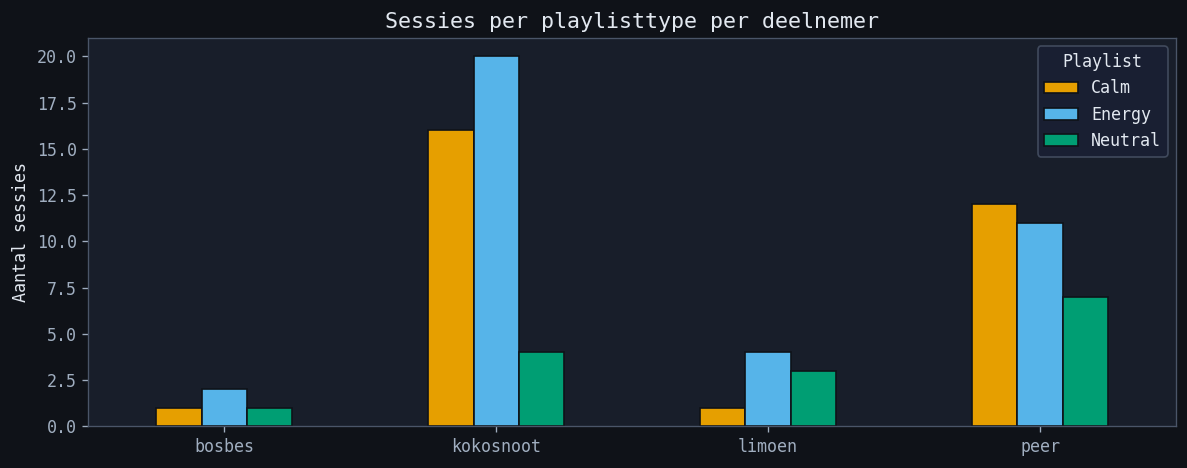

In [9]:
# Playlistdistributie per deelnemer
playlist_map = {1: "Calm", 0: "Neutral"}
def playlist_label(row):
    if row["playlist_calm"] == 1:
        return "Calm"
    elif row["playlist_energy"] == 1:
        return "Energy"
    return "Neutral"

fm["playlist_type"] = fm.apply(playlist_label, axis=1)
dist = fm.groupby(["participant", "playlist_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
dist.plot(kind="bar", ax=ax, color=OKABE_ITO[:3], edgecolor="#0f1218")
ax.set_title("Sessies per playlisttype per deelnemer", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Aantal sessies")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Playlist")
fig.tight_layout()
plt.show()

## 3. Modelresultaten

LOO-CV scores per model voor beide targets.
Lagere MAE = beter. R² < 0 = slechter dan het gemiddelde.
Overfitting-gap = R²_train − R²_LOO.

In [10]:
for target, label in TARGET_COLS.items():
    if target not in all_comparisons:
        continue
    comparison = all_comparisons[target]
    y          = all_y[target]
    dummy_mae  = comparison.loc[comparison["model"] == "DummyMean", "MAE"].values[0]

    print(f"\n{'═'*60}")
    print(f"  {label.upper()} ({target})  ·  {len(y)} sessies")
    print(f"{'═'*60}")
    display(comparison[["model", "MAE", "RMSE", "R2_LOO", "R2_train_mean", "overfit_gap"]].round(3))

    for _, row in comparison.iterrows():
        if row["model"] != "DummyMean" and row["overfit_gap"] > 0.5:
            print(f"  Overfit: {row['model']} — train R²={row['R2_train_mean']:.3f} vs LOO R²={row['R2_LOO']:.3f}")

    non_dummy = comparison[comparison["model"] != "DummyMean"]
    best_row  = non_dummy.loc[non_dummy["MAE"].idxmin()]
    print(f"  Beste model: {best_row['model']} (MAE={best_row['MAE']:.3f})")
    if best_row["MAE"] >= dummy_mae:
        print(f"  Geen model verslaat DummyMean — features voorspellen {target} niet beter dan het gemiddelde.")
    else:
        gain = (dummy_mae - best_row["MAE"]) / dummy_mae * 100
        print(f"  {gain:.1f}% verbetering t.o.v. DummyMean")


════════════════════════════════════════════════════════════
  STEMMING DELTA (mood_delta)  ·  82 sessies
════════════════════════════════════════════════════════════


,model,MAE,RMSE,R2_LOO,R2_train_mean,overfit_gap
0,DummyMean,1.817,2.460,-0.025,0.000,0.025
1,Ridge,1.578,2.007,0.318,0.587,0.269
2,RandomForest,1.666,2.128,0.233,0.681,0.448
3,GradientBoosting,1.778,2.295,0.108,0.820,0.712


  Overfit: GradientBoosting — train R²=0.820 vs LOO R²=0.108
  Beste model: Ridge (MAE=1.578)
  13.2% verbetering t.o.v. DummyMean

════════════════════════════════════════════════════════════
  STRESS DELTA (stress_delta)  ·  64 sessies
════════════════════════════════════════════════════════════


,model,MAE,RMSE,R2_LOO,R2_train_mean,overfit_gap
0,DummyMean,9.649,12.883,-0.032,0.000,0.032
1,Ridge,2.866,4.571,0.870,0.960,0.090
2,RandomForest,6.437,9.094,0.486,0.839,0.354
3,GradientBoosting,6.230,8.678,0.532,0.954,0.422


  Beste model: Ridge (MAE=2.866)
  70.3% verbetering t.o.v. DummyMean


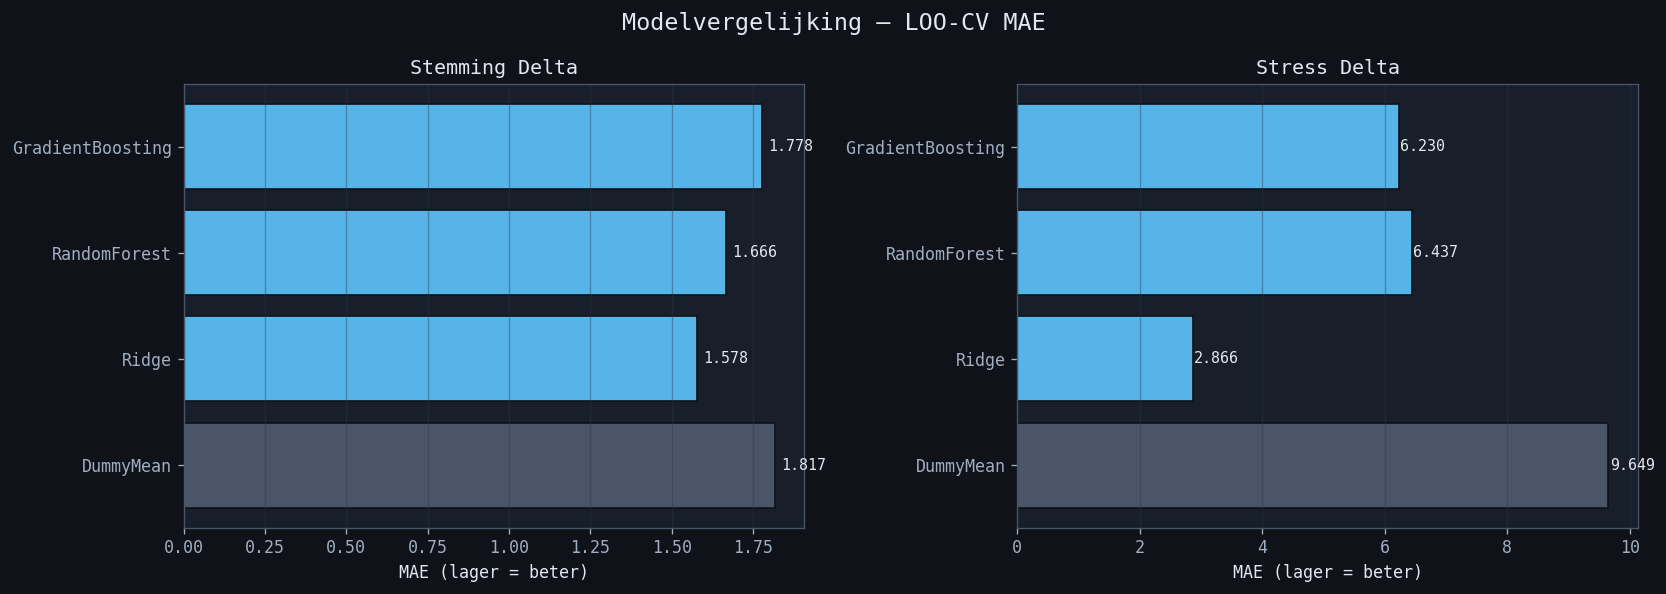

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_comparisons:
        continue
    comparison = all_comparisons[target]
    colors = ["#4a5568" if m == "DummyMean" else OKABE_ITO[1] for m in comparison["model"]]
    bars = ax.barh(comparison["model"], comparison["MAE"],
                   color=colors, edgecolor="#0f1218")
    for bar, v in zip(bars, comparison["MAE"]):
        ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)
    ax.set_xlabel("MAE (lager = beter)")
    ax.set_title(label, fontsize=12)
    ax.grid(True, axis="x")

fig.suptitle("Modelvergelijking — LOO-CV MAE", fontsize=14)
fig.tight_layout()
plt.show()

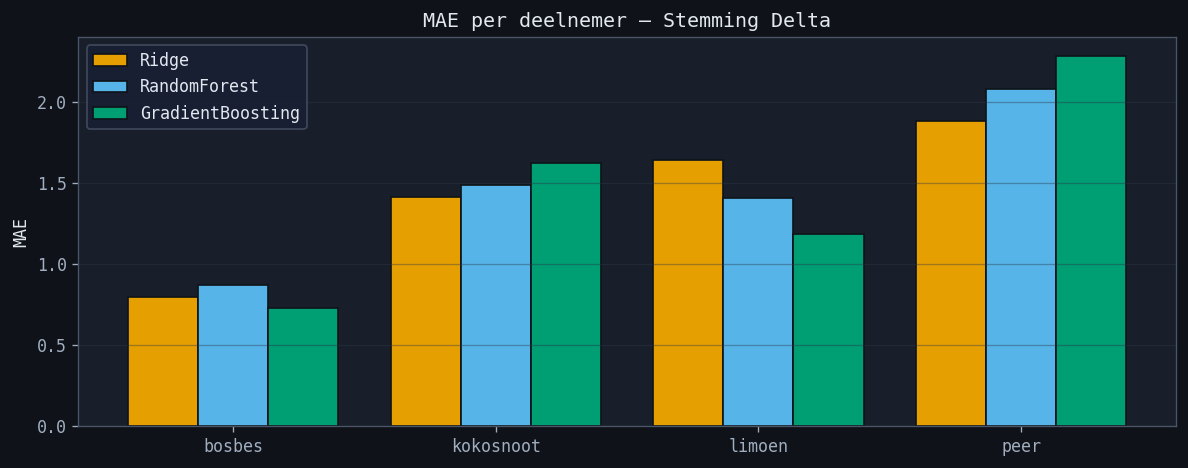

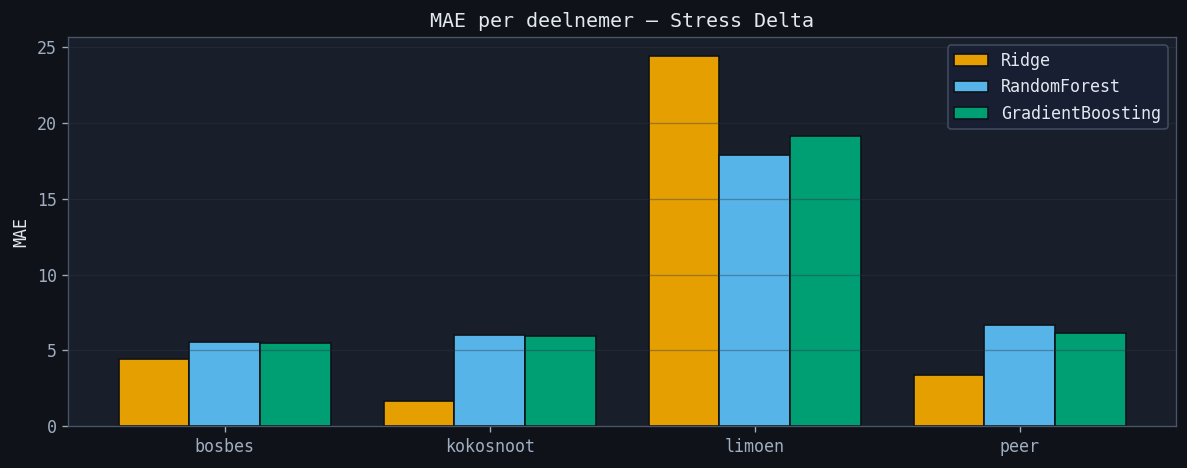

In [12]:
# Per-deelnemer MAE
for target, label in TARGET_COLS.items():
    if target not in all_comparisons:
        continue
    comparison  = all_comparisons[target]
    mae_cols    = [c for c in comparison.columns if c.startswith("MAE_")]
    if not mae_cols:
        continue
    parts       = [c.replace("MAE_", "") for c in mae_cols]
    non_dummy   = comparison[comparison["model"] != "DummyMean"].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    x     = np.arange(len(parts))
    width = 0.8 / len(non_dummy)

    for i, (_, row) in enumerate(non_dummy.iterrows()):
        vals = [row[c] for c in mae_cols]
        ax.bar(x + i * width, vals, width,
               label=row["model"], color=OKABE_ITO[i % len(OKABE_ITO)],
               edgecolor="#0f1218")

    ax.set_xticks(x + width * (len(non_dummy) - 1) / 2)
    ax.set_xticklabels(parts)
    ax.set_ylabel("MAE")
    ax.set_title(f"MAE per deelnemer — {label}", fontsize=12)
    ax.legend()
    ax.grid(True, axis="y")
    fig.tight_layout()
    plt.show()

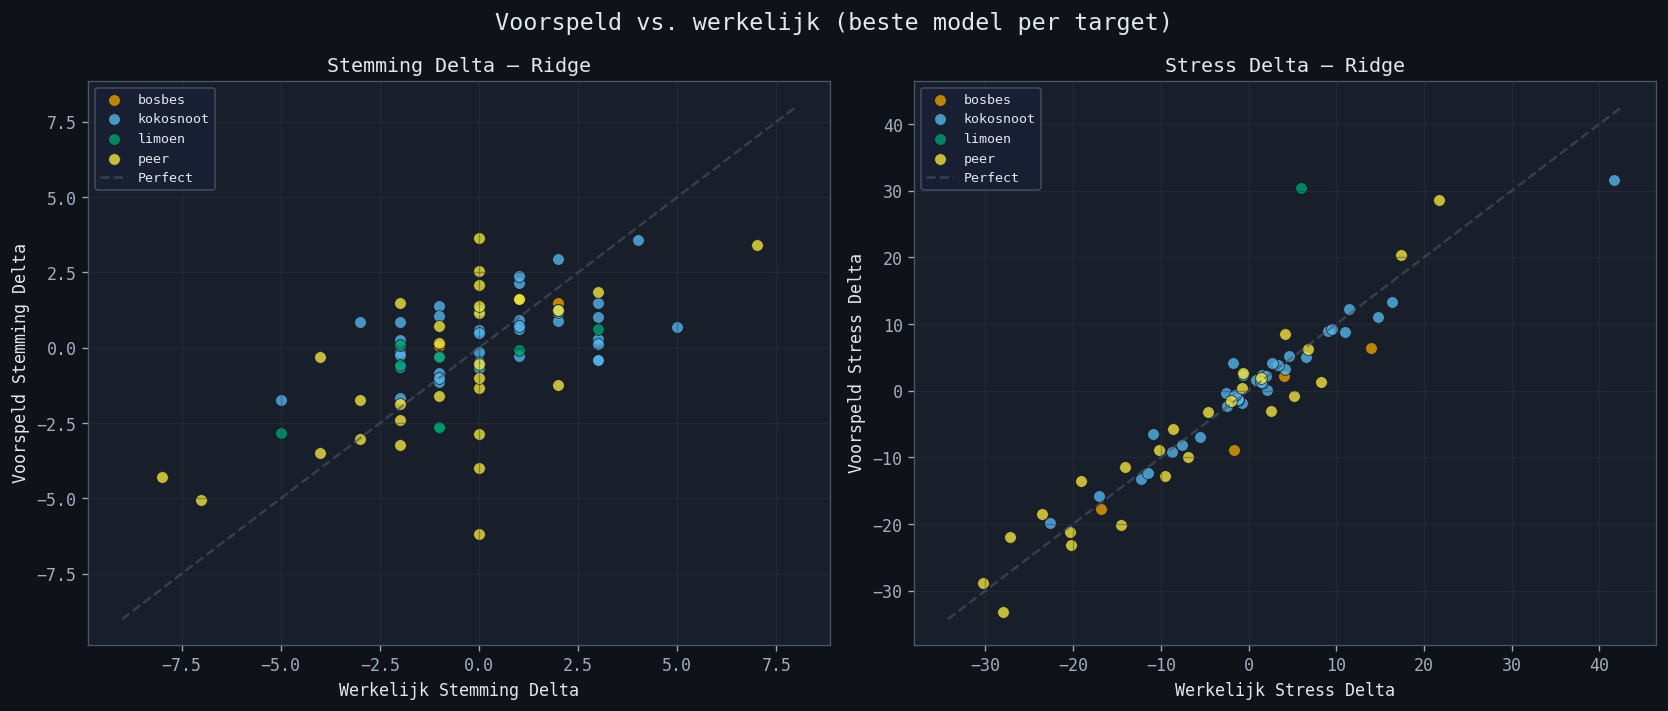

In [13]:
# Voorspeld vs. werkelijk — beste model per target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_comparisons:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]
    y_true     = all_y[target]
    y_pred     = all_results[target][best_name]["y_pred"]
    groups     = all_groups[target]

    for i, p in enumerate(groups.unique()):
        mask = groups == p
        ax.scatter(y_true[mask], y_pred[mask],
                   label=p, color=OKABE_ITO[i % len(OKABE_ITO)],
                   alpha=0.8, s=50, edgecolors="#0f1218", linewidths=0.5)

    mn = min(float(y_true.min()), float(y_pred.min())) - 1
    mx = max(float(y_true.max()), float(y_pred.max())) + 1
    ax.plot([mn, mx], [mn, mx], "--", color="#4a5568", alpha=0.6, label="Perfect")
    ax.set_xlabel(f"Werkelijk {label}")
    ax.set_ylabel(f"Voorspeld {label}")
    ax.set_title(f"{label} — {best_name}", fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle("Voorspeld vs. werkelijk (beste model per target)", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Verklarende analyse

Ridge coëfficiënten, permutation importance en SHAP zijn **verklarend** — ze beschrijven het model,
niet noodzakelijk de werkelijkheid. Met N < 100 en hoge NaN-fracties zijn dit richtingwijzers,
geen causale uitspraken.

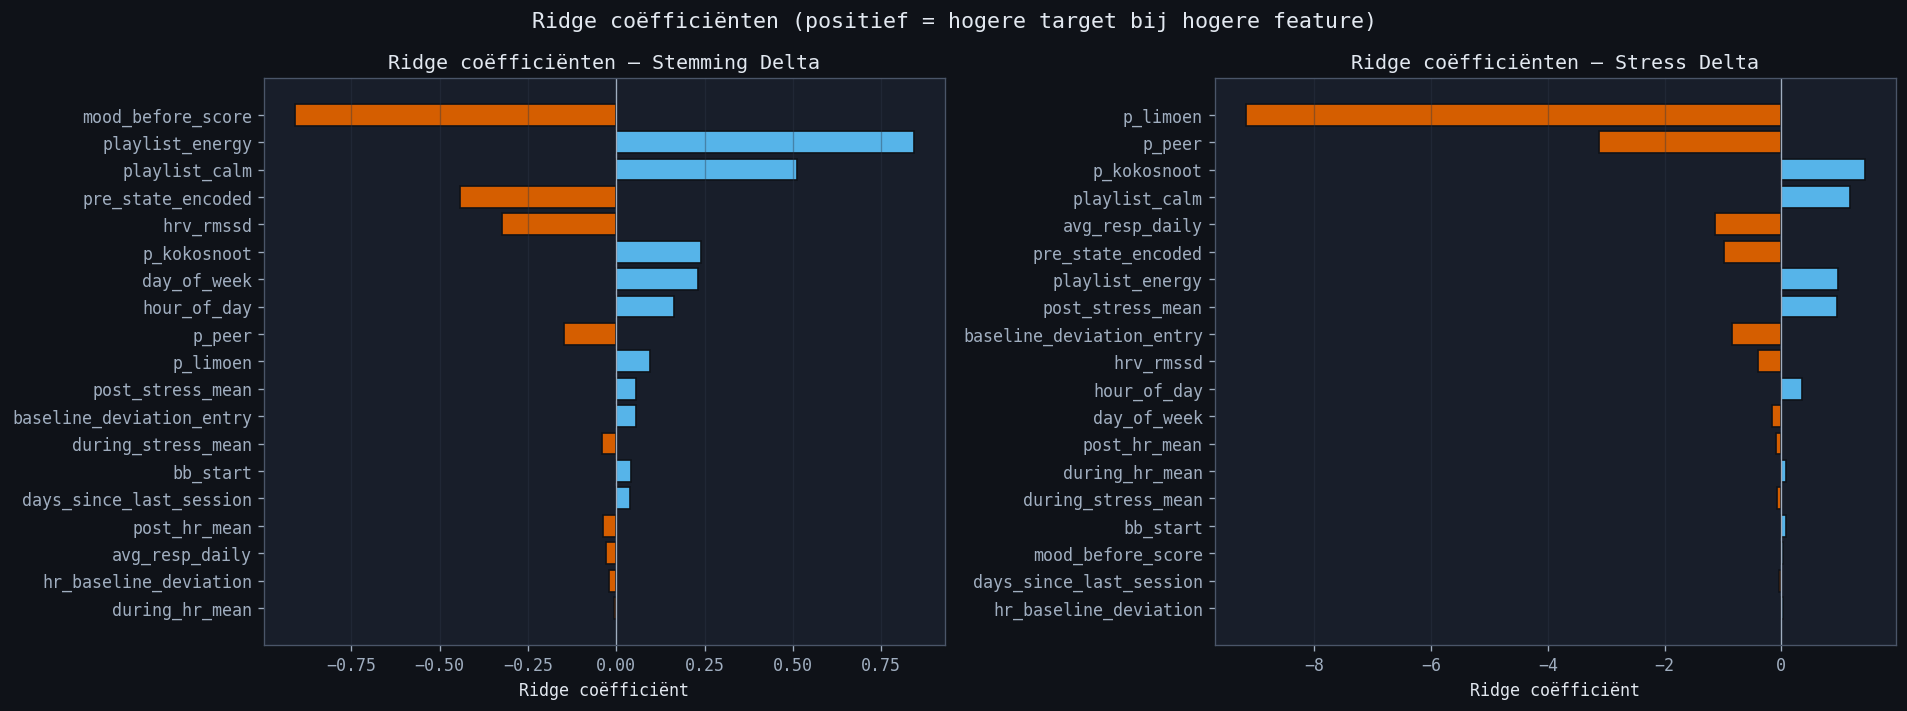

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_fitted:
        continue
    pipe   = all_fitted[target]["Ridge"]
    X      = all_X[target]
    coefs  = pipe.named_steps["model"].coef_
    names  = feature_names if feature_names else list(X.columns)

    coef_df = pd.DataFrame({"feature": names, "coef": coefs})
    coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=True).index)
    colors  = [OKABE_ITO[5] if c < 0 else OKABE_ITO[1] for c in coef_df["coef"]]

    ax.barh(coef_df["feature"], coef_df["coef"],
            color=colors, edgecolor="#0f1218")
    ax.axvline(0, color="#a0aec0", linewidth=0.8)
    ax.set_xlabel("Ridge coëfficiënt")
    ax.set_title(f"Ridge coëfficiënten — {label}", fontsize=12)
    ax.grid(True, axis="x")

fig.suptitle("Ridge coëfficiënten (positief = hogere target bij hogere feature)",
             fontsize=13)
fig.tight_layout()
plt.show()

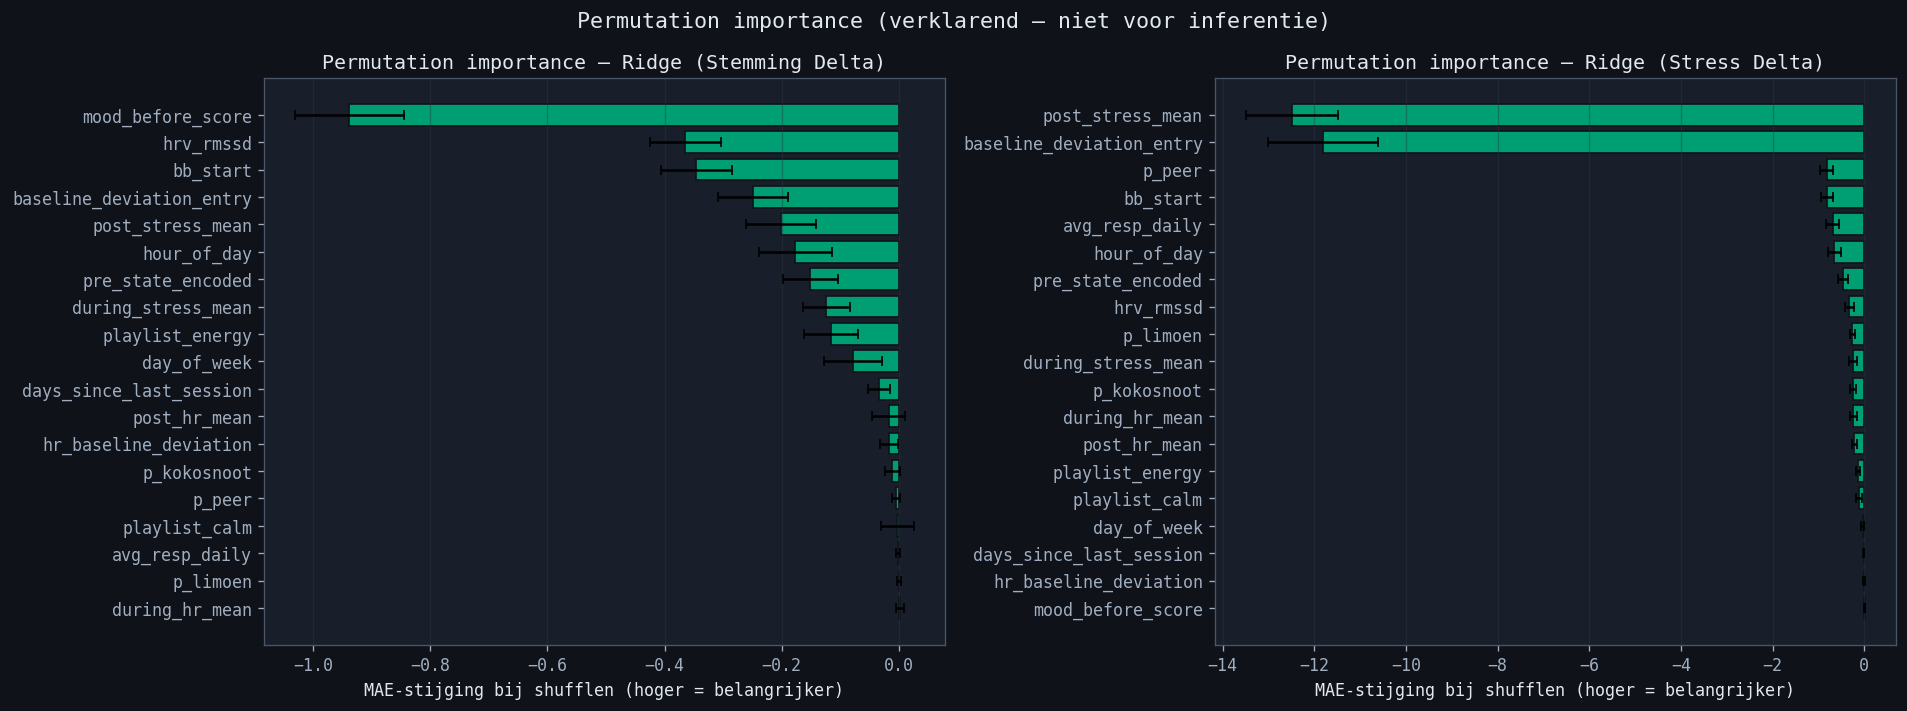

In [15]:
# Permutation importance — beste model per target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (target, label) in zip(axes, TARGET_COLS.items()):
    if target not in all_fitted:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]

    pipe = all_fitted[target][best_name]
    X    = all_X[target]
    y    = all_y[target]

    result = permutation_importance(
        pipe, X, y, n_repeats=30, random_state=42,
        scoring="neg_mean_absolute_error",
    )
    perm_df = pd.DataFrame({
        "feature":   list(X.columns),
        "mean":      result.importances_mean,
        "std":       result.importances_std,
    }).sort_values("mean", ascending=True)

    ax.barh(perm_df["feature"], -perm_df["mean"],
            xerr=perm_df["std"], color=OKABE_ITO[2],
            edgecolor="#0f1218", capsize=3)
    ax.set_xlabel("MAE-stijging bij shufflen (hoger = belangrijker)")
    ax.set_title(f"Permutation importance — {best_name} ({label})", fontsize=12)
    ax.grid(True, axis="x")

fig.suptitle("Permutation importance (verklarend — niet voor inferentie)", fontsize=13)
fig.tight_layout()
plt.show()


SHAP — Stemming Delta (Ridge, N=82)
Betrouwbaarheid: GRENSGEBIED — gebruik als richtingwijzer.


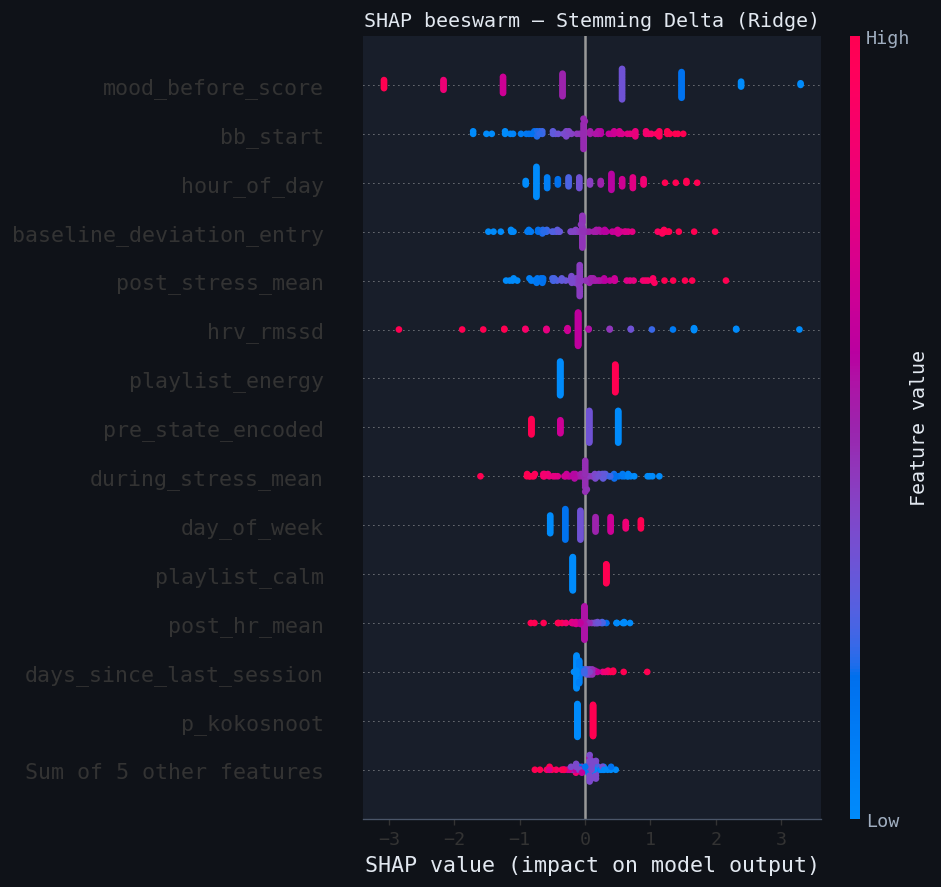


SHAP — Stress Delta (Ridge, N=64)
Betrouwbaarheid: GRENSGEBIED — gebruik als richtingwijzer.


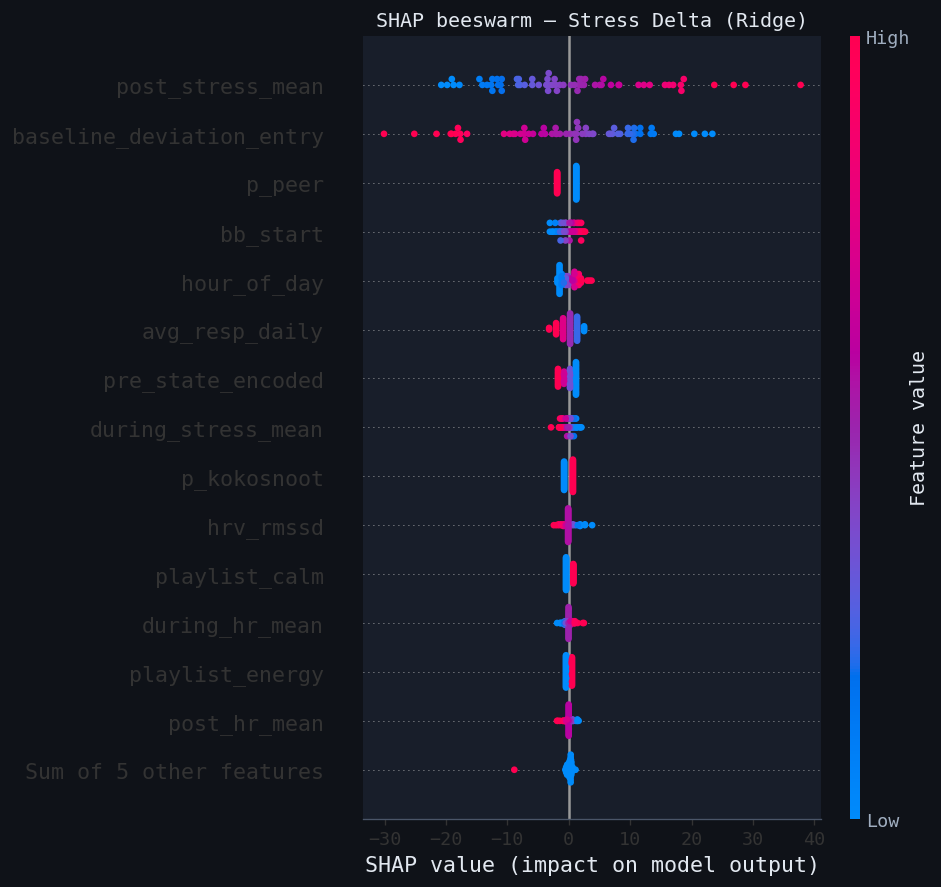

In [16]:
# SHAP — gecombineerd (alle deelnemers)
for target, label in TARGET_COLS.items():
    if target not in all_fitted:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]

    pipe    = all_fitted[target][best_name]
    X       = all_X[target]
    imputer = pipe.named_steps["imputer"]

    X_imp  = imputer.transform(X)
    mask   = ~np.isnan(imputer.statistics_)
    kept   = [c for c, k in zip(X.columns, mask) if k]
    X_imp  = pd.DataFrame(X_imp, columns=kept)

    model    = pipe.named_steps["model"]
    explainer = shap.Explainer(model, X_imp)
    shap_vals = explainer(X_imp)

    print(f"\nSHAP — {label} ({best_name}, N={len(X)})")
    print(f"Betrouwbaarheid: {'LAAG' if len(X) < 40 else 'GRENSGEBIED'} — gebruik als richtingwijzer.")

    fig_sv, ax_sv = plt.subplots(figsize=(10, 6))
    plt.sca(ax_sv)
    shap.plots.beeswarm(shap_vals, show=False, max_display=15)
    ax_sv.set_title(f"SHAP beeswarm — {label} ({best_name})", fontsize=12)
    fig_sv.tight_layout()
    plt.show()

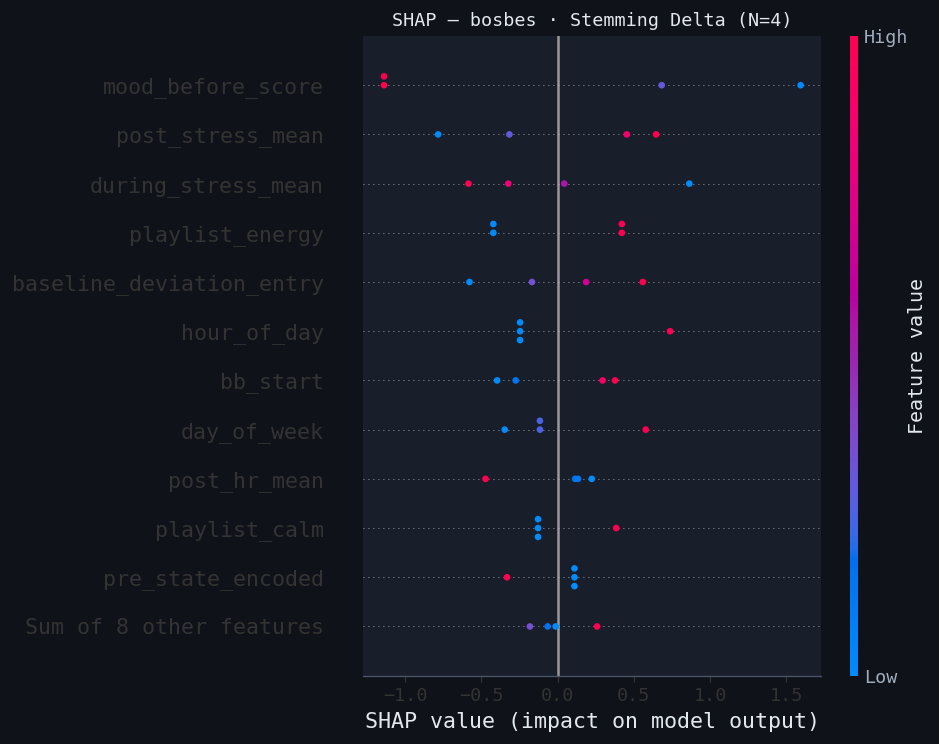

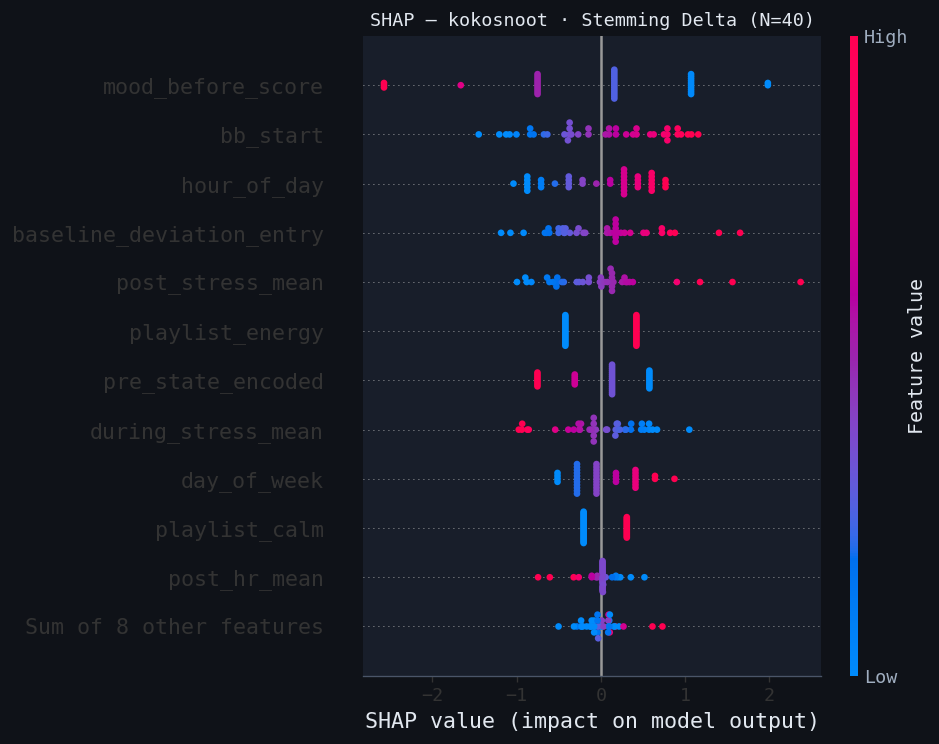

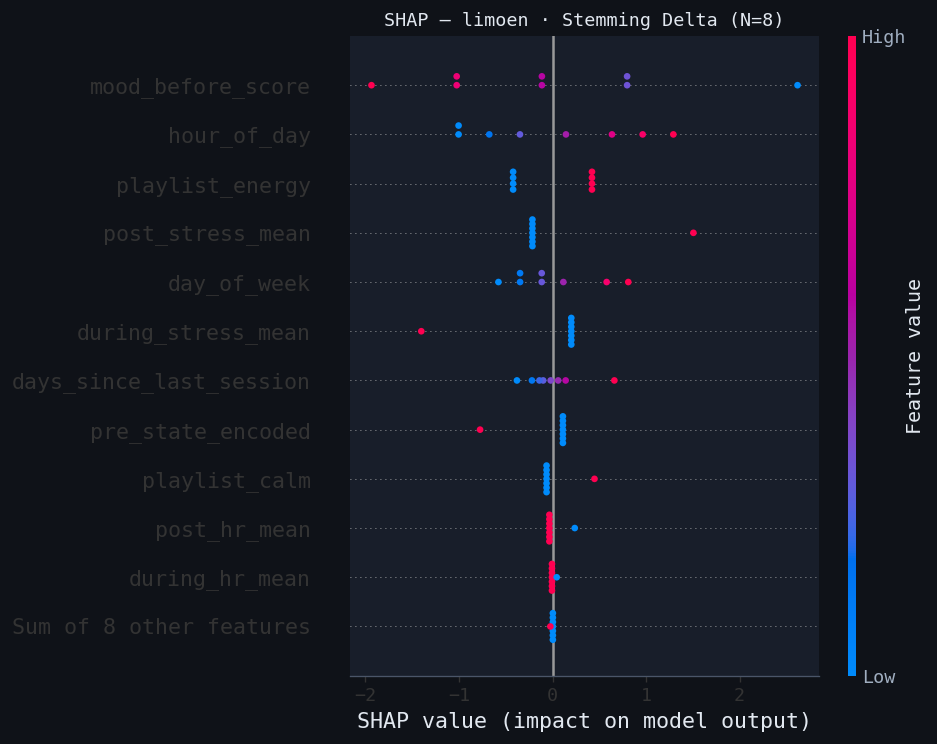

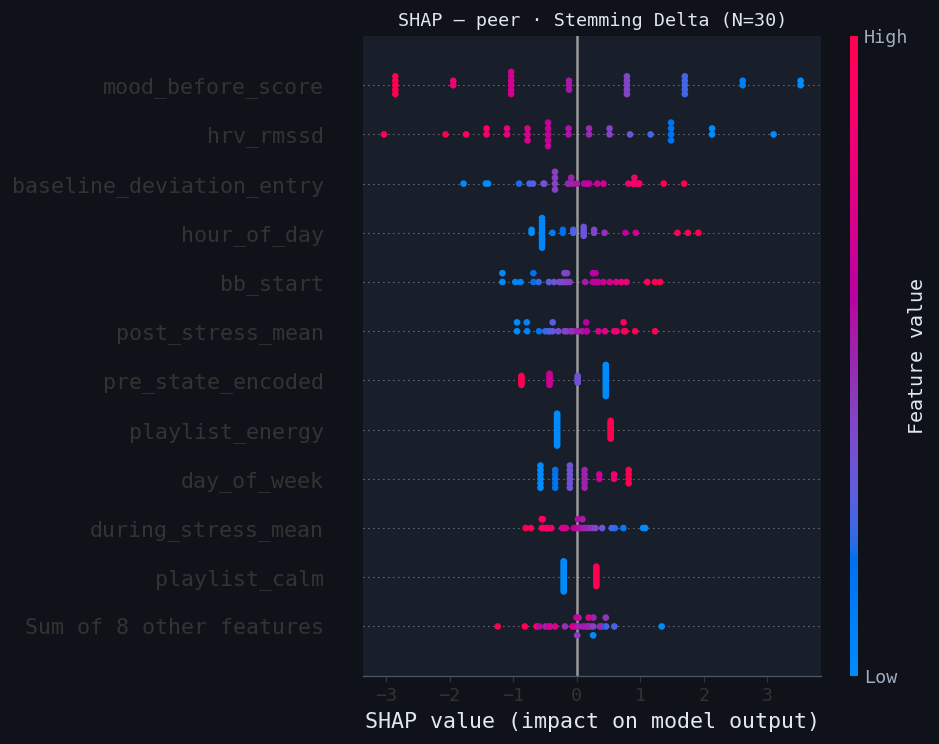

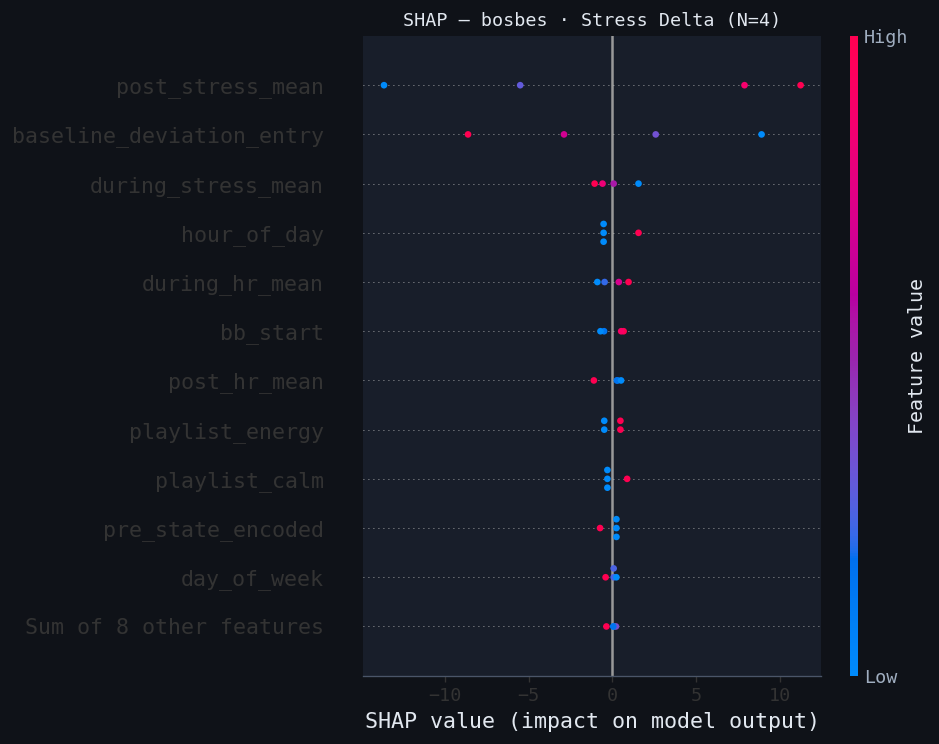

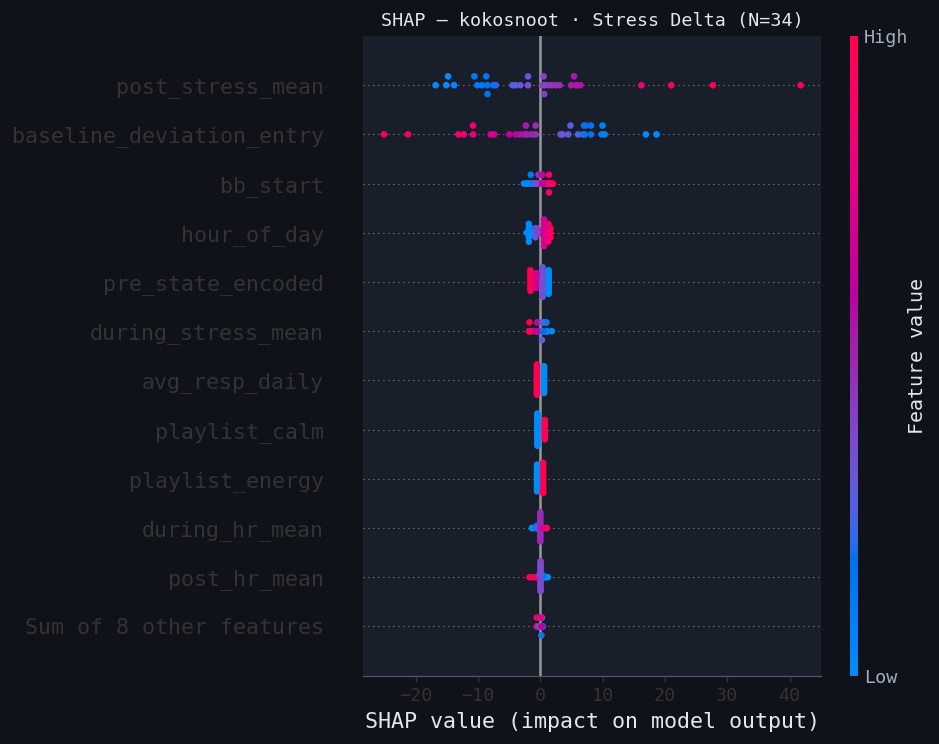

  limoen: te weinig sessies voor SHAP (1)


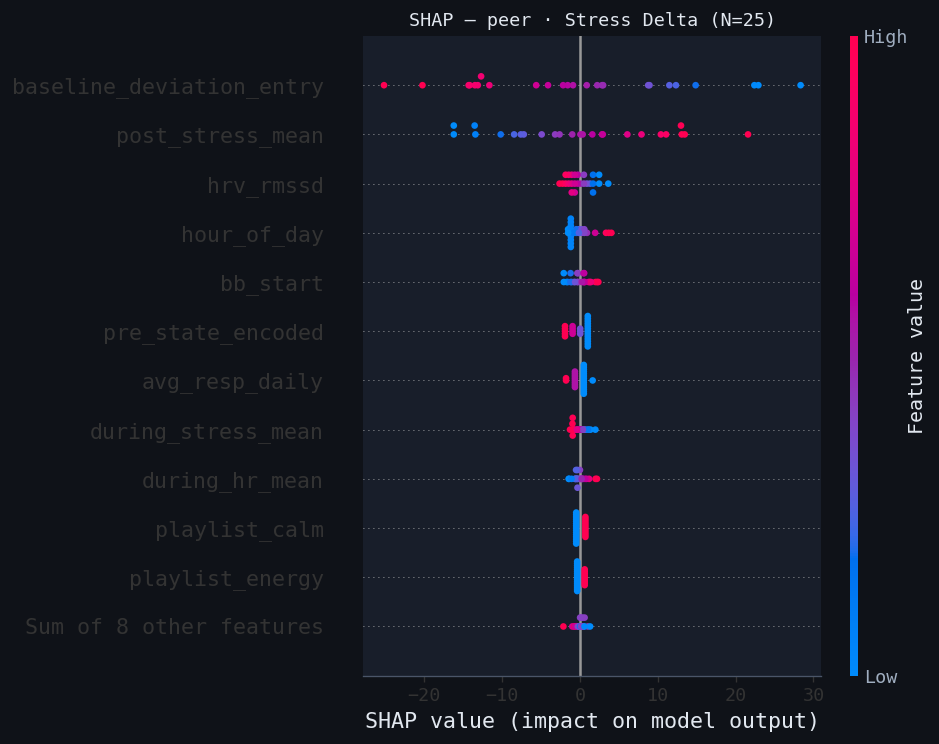

In [17]:
# SHAP — per deelnemer (minimaal 3 sessies)
for target, label in TARGET_COLS.items():
    if target not in all_fitted:
        continue
    comparison = all_comparisons[target]
    non_dummy  = comparison[comparison["model"] != "DummyMean"]
    best_name  = non_dummy.loc[non_dummy["MAE"].idxmin(), "model"]

    X      = all_X[target]
    y      = all_y[target]
    groups = all_groups[target]
    pipe   = all_fitted[target][best_name]

    for p in participants:
        mask = groups == p
        if mask.sum() < 3:
            print(f"  {p}: te weinig sessies voor SHAP ({mask.sum()})")
            continue

        X_p      = X[mask]
        imputer  = pipe.named_steps["imputer"]
        X_imp    = imputer.transform(X_p)
        kept_mask = ~np.isnan(imputer.statistics_)
        kept     = [c for c, k in zip(X_p.columns, kept_mask) if k]
        X_imp    = pd.DataFrame(X_imp, columns=kept)

        model     = pipe.named_steps["model"]
        explainer = shap.Explainer(model, X_imp)
        shap_vals = explainer(X_imp)

        fig_p, ax_p = plt.subplots(figsize=(9, 5))
        plt.sca(ax_p)
        shap.plots.beeswarm(shap_vals, show=False, max_display=12)
        ax_p.set_title(f"SHAP — {p} · {label} (N={mask.sum()})", fontsize=11)
        fig_p.tight_layout()
        plt.show()

## 5. Stress delta — toelichting

`stress_delta` = post_stress − pre_stress. Een negatieve waarde betekent dat stress daalde
tijdens de sessie. Limoen heeft slechts 1 geldige sessie voor dit target.

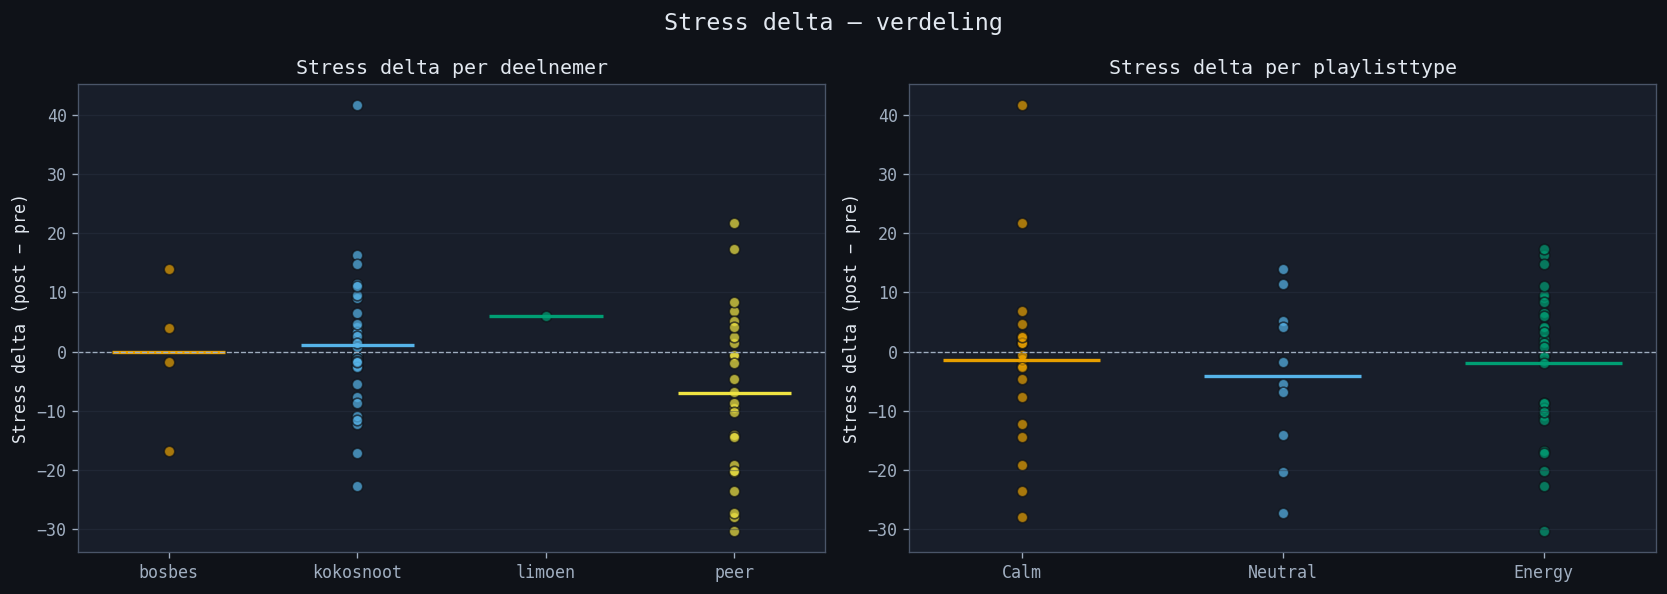

In [18]:
if "stress_delta" in all_y:
    y_sd     = all_y["stress_delta"]
    groups_sd = all_groups["stress_delta"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Verdeling per deelnemer
    ax = axes[0]
    for i, p in enumerate(groups_sd.unique()):
        vals = y_sd[groups_sd == p]
        ax.scatter([p] * len(vals), vals,
                   color=OKABE_ITO[i % len(OKABE_ITO)],
                   alpha=0.7, s=40, edgecolors="#0f1218")
        ax.hlines(vals.mean(), i - 0.3, i + 0.3,
                  colors=OKABE_ITO[i % len(OKABE_ITO)], linewidth=2)
    ax.axhline(0, color="#a0aec0", linewidth=0.8, linestyle="--")
    ax.set_title("Stress delta per deelnemer", fontsize=12)
    ax.set_ylabel("Stress delta (post − pre)")
    ax.grid(True, axis="y")

    # Verdeling per playlist
    ax = axes[1]
    fm_sd = fm[fm["stress_delta"].notna()].copy()
    for i, ptype in enumerate(["Calm", "Neutral", "Energy"]):
        vals = fm_sd.loc[fm_sd["playlist_type"] == ptype, "stress_delta"]
        if vals.empty:
            continue
        ax.scatter([ptype] * len(vals), vals,
                   color=OKABE_ITO[i % len(OKABE_ITO)],
                   alpha=0.7, s=40, edgecolors="#0f1218")
        ax.hlines(vals.mean(), i - 0.3, i + 0.3,
                  colors=OKABE_ITO[i % len(OKABE_ITO)], linewidth=2)
    ax.axhline(0, color="#a0aec0", linewidth=0.8, linestyle="--")
    ax.set_title("Stress delta per playlisttype", fontsize=12)
    ax.set_ylabel("Stress delta (post − pre)")
    ax.grid(True, axis="y")

    fig.suptitle("Stress delta — verdeling", fontsize=14)
    fig.tight_layout()
    plt.show()

## 6. Robuustheidschecks

### 6a. Leave-One-Participant-Out (LOPO)

Test of de patronen generaliseren over deelnemers. Met 4 deelnemers is dit een harde test.
Hogere MAE dan LOO-CV = patronen zijn deelnemersspecifiek.

In [19]:
from sklearn.model_selection import LeaveOneGroupOut

MODELS_LOPO = {
    "Ridge":            Ridge(alpha=1.0),
    "RandomForest":     RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                                   learning_rate=0.1, random_state=42),
}

logo = LeaveOneGroupOut()

for target, label in TARGET_COLS.items():
    if target not in all_X:
        continue
    X      = all_X[target]
    y      = all_y[target]
    groups = all_groups[target]

    print(f"\n{'═'*50}")
    print(f"  LOPO — {label}  (N={len(y)})")
    print(f"{'═'*50}")

    for name, model in MODELS_LOPO.items():
        preds = np.full(len(y), np.nan)
        for train_idx, test_idx in logo.split(X, y, groups):
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model",   clone(model)),
            ])
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds[test_idx] = pipe.predict(X.iloc[test_idx])
        mae = mean_absolute_error(y, preds)
        loo_mae = all_comparisons[target].loc[
            all_comparisons[target]["model"] == name, "MAE"
        ].values[0]
        print(f"  {name:20s}: LOPO MAE={mae:.3f}  (LOO MAE={loo_mae:.3f})")


══════════════════════════════════════════════════
  LOPO — Stemming Delta  (N=82)
══════════════════════════════════════════════════
  Ridge               : LOPO MAE=2.104  (LOO MAE=1.578)
  RandomForest        : LOPO MAE=1.646  (LOO MAE=1.666)
  GradientBoosting    : LOPO MAE=1.671  (LOO MAE=1.778)

══════════════════════════════════════════════════
  LOPO — Stress Delta  (N=64)
══════════════════════════════════════════════════
  Ridge               : LOPO MAE=5.868  (LOO MAE=2.866)
  RandomForest        : LOPO MAE=7.373  (LOO MAE=6.437)
  GradientBoosting    : LOPO MAE=7.098  (LOO MAE=6.230)


### 6b. Ablatie — zonder `mood_before_score`

Checkt of de andere features bijdragen voorbij regressie-naar-het-gemiddelde.
Als MAE sterk stijgt bij weglaten van `mood_before_score`, drijven die andere features
de voorspelling.

In [20]:
target = "mood_delta"
if target in all_X:
    X      = all_X[target]
    y      = all_y[target]
    model  = GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                       learning_rate=0.1, random_state=42)
    loo    = LeaveOneOut()

    print(f"Ablatie — {TARGET_COLS[target]}\n")

    for include_mood in [True, False]:
        lbl   = "MET mood_before_score" if include_mood else "ZONDER mood_before_score"
        X_sub = X[[c for c in X.columns if include_mood or c != "mood_before_score"]]

        y_pred = np.full(len(y), np.nan)
        for train_idx, test_idx in loo.split(X_sub):
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model",   clone(model)),
            ])
            pipe.fit(X_sub.iloc[train_idx], y.iloc[train_idx])
            y_pred[test_idx] = pipe.predict(X_sub.iloc[test_idx])

        mae = mean_absolute_error(y, y_pred)
        r2  = r2_score(y, y_pred)
        print(f"  {lbl}: MAE={mae:.3f}, R²_LOO={r2:.3f}")

Ablatie — Stemming Delta

  MET mood_before_score: MAE=1.778, R²_LOO=0.108
  ZONDER mood_before_score: MAE=2.126, R²_LOO=-0.306
